In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from sklearn.model_selection import StratifiedShuffleSplit
import timm
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import time


In [5]:
# Set the device for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [6]:
# Hyperparameters
batch_size = 16
learning_rate = 1e-4
num_epochs = 50
patience = 5
test_split_ratio = 0.2
dropout_rate = 0.3

# Data preprocessing
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [7]:
# Dataset paths
data_dir = "C:/Users/Dell/Desktop/ML_CP/DATASET/IHDS_dataset"

# Load dataset and create stratified split
train_full_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=preprocess)
val_dataset = datasets.ImageFolder(root=f"{data_dir}/val", transform=preprocess)

# Stratified splitting for train and test
labels = [label for _, label in train_full_dataset]
sss = StratifiedShuffleSplit(n_splits=1, test_size=test_split_ratio, random_state=42)
train_indices, test_indices = next(sss.split(np.zeros(len(labels)), labels))

train_dataset = Subset(train_full_dataset, train_indices)
test_dataset = Subset(train_full_dataset, test_indices)

# Dataloaders
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
    'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=False),
}
print(f"Train samples: {len(train_dataset)}, Test samples: {len(test_dataset)}")


Train samples: 1914, Test samples: 479


In [8]:
# Define model
model = timm.create_model('mobilenetv4_conv_medium.e500_r256_in1k', num_classes=50, pretrained=True)
model.dropout = nn.Dropout(dropout_rate)
model = model.to(device)
print(model)


MobileNetV3(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): EdgeResidual(
        (conv_exp): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): Identity()
        (conv_pwl): Conv2d(128, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
        (drop_path): Identity()
      )
    )
    (1): Sequential(
      (0): Uni

In [6]:
# Loss function, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Training loop with early stopping
best_val_acc = 0.0
early_stopping_counter = 0
model_save_path = "AA_DECEMEBR.pth"
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    for images, labels in dataloaders['train']:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted_train = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted_train == labels).sum().item()
    train_acc = 100 * correct_train / total_train
    train_accuracies.append(train_acc)

    # Validation phase
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in dataloaders['val']:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted_val = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted_val == labels).sum().item()
    val_acc = 100 * correct_val / total_val
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        early_stopping_counter = 0
        torch.save(model.state_dict(), model_save_path)
    else:
        early_stopping_counter += 1

    if early_stopping_counter >= patience:
        print("Early stopping triggered.")
        break

    scheduler.step()


Epoch [1/50] Train Acc: 38.61%, Val Acc: 80.76%
Epoch [2/50] Train Acc: 93.10%, Val Acc: 92.54%
Epoch [3/50] Train Acc: 98.69%, Val Acc: 95.36%
Epoch [4/50] Train Acc: 99.63%, Val Acc: 96.02%
Epoch [5/50] Train Acc: 99.90%, Val Acc: 95.19%
Epoch [6/50] Train Acc: 100.00%, Val Acc: 96.02%
Epoch [7/50] Train Acc: 99.95%, Val Acc: 96.68%
Epoch [8/50] Train Acc: 100.00%, Val Acc: 96.19%
Epoch [9/50] Train Acc: 100.00%, Val Acc: 96.85%
Epoch [10/50] Train Acc: 100.00%, Val Acc: 96.85%
Epoch [11/50] Train Acc: 99.95%, Val Acc: 96.68%
Epoch [12/50] Train Acc: 99.95%, Val Acc: 97.18%
Epoch [13/50] Train Acc: 100.00%, Val Acc: 97.01%
Epoch [14/50] Train Acc: 99.95%, Val Acc: 96.68%
Epoch [15/50] Train Acc: 99.90%, Val Acc: 97.35%
Epoch [16/50] Train Acc: 100.00%, Val Acc: 97.35%
Epoch [17/50] Train Acc: 99.95%, Val Acc: 97.01%
Epoch [18/50] Train Acc: 100.00%, Val Acc: 96.68%
Epoch [19/50] Train Acc: 100.00%, Val Acc: 96.52%
Epoch [20/50] Train Acc: 99.95%, Val Acc: 97.35%
Early stopping trigge

In [17]:
import torch
import torch.nn as nn
import torch.quantization

# Apply 8-bit quantization using built-in methods
def apply_8bit_quantization(model):
    model = model.to('cpu')  # Ensure model is on CPU (for quantization)
    
    # Use PyTorch's built-in dynamic quantization for 8-bit
    model = torch.quantization.quantize_dynamic(
        model, 
        dtype=torch.qint8,  # Specifies 8-bit integer type
        inplace=True
    )
    return model

# Example of quantizing the model
def apply_custom_quantization(model, num_bits=4):
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            with torch.no_grad():
                print(f"\nQuantizing weights for layer: {name}")
                print("Before quantization (4th and 5th sample):")
                print(module.weight.data.flatten()[3:5])  # Print 4th and 5th weights before quantization
                
                # Quantize and dequantize weights manually
                if num_bits == 8:
                    # Apply 8-bit quantization using the built-in method
                    model = apply_8bit_quantization(model)
                
                # Print the quantized weights after applying 8-bit quantization
                print("After quantization (4th and 5th sample):")
                print(module.weight.data.flatten()[3:5])  # Print 4th and 5th weights after quantization
    return model

# Example usage of quantization
# Apply custom quantization with 8 bits
model_8bit = apply_custom_quantization(model, num_bits=8)



Quantizing weights for layer: classifier
Before quantization (4th and 5th sample):
tensor([0.0947, 0.0717])
After quantization (4th and 5th sample):
tensor([0.0947, 0.0717])


In [18]:
# Apply quantization
# Example usage of quantization
# Apply custom quantization with 8 bits
model_8bit = apply_8bit_quantization(model)


# Save quantized models
torch.save(model_8bit.state_dict(), "4bit_model.pth")



In [19]:
# Calculate model sizes before and after quantization (4 bits per parameter for 4-bit)
model_size_before = sum(p.numel() for p in model.parameters()) * (32 / 8) / 1e6  # 32 bits per parameter for full precision
model_size_4bit = sum(p.numel() for p in model_8bit.parameters()) * (4 / 8) / 1e6  # 4 bits per parameter


# Print model sizes
print(f"Model Size Before Quantization: {model_size_before:.2f} MB")
print(f"Model Size After 4-bit Quantization: {model_size_4bit:.2f} MB")


# Accuracy testing for 4-bit and 6-bit models
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloaders['test']:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy






Model Size Before Quantization: 33.99 MB
Model Size After 4-bit Quantization: 4.25 MB


In [14]:
# Cell 16: Set Up Inference for a Single Image
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

data_dir = "C:/Users/Dell/Desktop/ML_CP/DATASET/IHDS_dataset"
train_dataset = datasets.ImageFolder(root=f"{data_dir}/train", transform=preprocess)
class_names = train_dataset.classes  # Extract class labels from the dataset


In [48]:
# Cell 17: Load Model for Inference
model = timm.create_model('mobilenetv4_conv_medium.e500_r256_in1k', num_classes=50, pretrained=False)
model.load_state_dict(torch.load(r"C:\Users\Dell\Desktop\ML_CP\FINAL_fulll_2.pth", map_location=device))
model = model.to(device)
model.eval()  # Set model to evaluation mode


C:\Users\Dell\AppData\Local\Temp\ipykernel_26572\499121541.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(r"C:\Users\Dell\Desktop\ML_CP

MobileNetV3(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): EdgeResidual(
        (conv_exp): Conv2d(32, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (se): Identity()
        (conv_pwl): Conv2d(128, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNormAct2d(
          48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): Identity()
        )
        (drop_path): Identity()
      )
    )
    (1): Sequential(
      (0): Uni

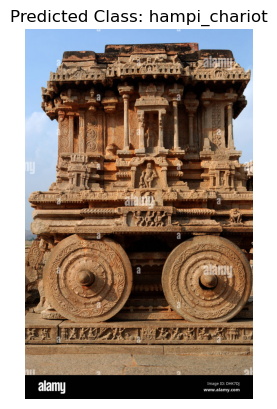

In [49]:
# Cell 19: Display Test Image and Predicted Class
import matplotlib.pyplot as plt

def infer_and_display(image_path, model, class_names):
    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    preprocessed_image = preprocess(image).unsqueeze(0).to(device)

    # Perform inference
    with torch.no_grad():
        outputs = model(preprocessed_image)
        _, predicted = torch.max(outputs, 1)
        class_name = class_names[predicted.item()]

    # Display the image and prediction
    plt.imshow(image)
    plt.title(f"Predicted Class: {class_name}")
    plt.axis("off")
    plt.show()

# Example inference and display on a sample image
sample_image_path = r"C:\Users\Dell\Desktop\ML_CP\hampi_chariot.jpg"
infer_and_display(sample_image_path, model, class_names)
